In [1]:
import json
import weave
import matplotlib.pyplot as plt

from thefuzz import fuzz
from util.insert_parser import parse_insert

client = weave.init("leonkrueger02/mt_justine")
all_calls = client.get_calls()

weave: weave version 0.53.2 is available!  To upgrade, please run:
weave:  $ pip install weave --upgrade
weave: Logged in as Weights & Biases user: leonkrueger.
weave: View Weave data at https://wandb.ai/leonkrueger02/mt_justine/weave


In [3]:
is_relevant_call = lambda call: (call.attributes.get("justine_version") == "justine_3_3_retry_with_feedback_two_shot")

calls = [call for call in all_calls if is_relevant_call(call)]
num_inserts = len([c for c in calls if c.attributes.get("prediction_attempt") == 1])
print(f"Found {len(calls)} relevant calls for {num_inserts} inserts.")

Found 1039 relevant calls for 920 inserts.


In [3]:
latencies = [(call.ended_at - call.started_at).total_seconds() for call in calls]
print(f"Average latency: {sum(latencies) / len(latencies)} seconds per call, {sum(latencies) / num_inserts} seconds per insert.")

Average latency: 13.941844316335349 seconds per call, 17.41977740172786 seconds per insert.


## Find databases with wrong number of predicted columns

In [4]:
def find_calls_with_error(error_name: str):
    mismatched_calls = []

    for call in calls:
        # Skip traces that failed or didn't return properly
        if not call.output:
            continue

        if call.attributes.get("prediction_attempt") != 3:
            continue
            
        try:
            error = call.output.get("prediction_error", None)
            if error == error_name:
                mismatched_calls.append(call)
        except Exception as e:
            # Handle cases where the LLM output was malformed
            pass

    print(f"Found {len(mismatched_calls)} examples with error '{error_name}'.")
    print(f"Databases with mismatched calls: {set([call.attributes.get('database_name') for call in mismatched_calls])}")

    number_of_columns = [c.attributes.get("insert_column_number") for c in mismatched_calls]
    if len(number_of_columns) > 0:
        print(f"Number of columns statistics: min={min(number_of_columns)}, max={max(number_of_columns)}, mean={sum(number_of_columns)/len(number_of_columns)}\n")
    else:
        print()

    # 4. Print the direct UI links to investigate the complex examples
    # for i, call in enumerate(mismatched_calls[:5]):
    #     print(f"Query: {call.attributes.get('insert_full')}")
    #     print(f"Predicted columns: {call.output.get('predicted_column_names')}\n")

def find_calls_with_duplicate_columns():
    duplicate_calls = []

    for call in calls:
        # Skip traces that failed or didn't return properly
        if not call.output:
            continue

        if call.output.get("prediction_error") is not None:
            continue
            
        try:
            cols = call.output.get("predicted_column_names", [])
            if len(cols) != len(set(cols)):
                duplicate_calls.append(call)
        except Exception as e:
            # Handle cases where the LLM output was malformed
            pass

    print(f"Found {len(duplicate_calls)} examples with duplicate column names.")
    print(f"Databases with duplicate column calls: {set([call.attributes.get('database_name') for call in duplicate_calls])}")


    number_of_columns = [c.attributes.get("insert_column_number") for c in duplicate_calls]
    if len(number_of_columns) > 0:
        print(f"Number of columns statistics: min={min(number_of_columns)}, max={max(number_of_columns)}, mean={sum(number_of_columns)/len(number_of_columns)}\n")

find_calls_with_error("IncorrectNumberOfColumnsError")
find_calls_with_error("JSONDecodeError")
find_calls_with_error("DuplicateColumnNamesError")
find_calls_with_error("AlignmentMismatchError")
find_calls_with_duplicate_columns()

Found 0 examples with error 'IncorrectNumberOfColumnsError'.
Databases with mismatched calls: set()

Found 1 examples with error 'JSONDecodeError'.
Databases with mismatched calls: {'spider2_Airlines'}
Number of columns statistics: min=5, max=5, mean=5.0

Found 7 examples with error 'DuplicateColumnNamesError'.
Databases with mismatched calls: {'spider2_California_Traffic_Collision', 'spider2_EU_soccer'}
Number of columns statistics: min=58, max=112, mean=81.28571428571429

Found 2 examples with error 'AlignmentMismatchError'.
Databases with mismatched calls: {'spider2_EU_soccer', 'spider2_Airlines'}
Number of columns statistics: min=5, max=106, mean=55.5

Found 0 examples with duplicate column names.
Databases with duplicate column calls: set()


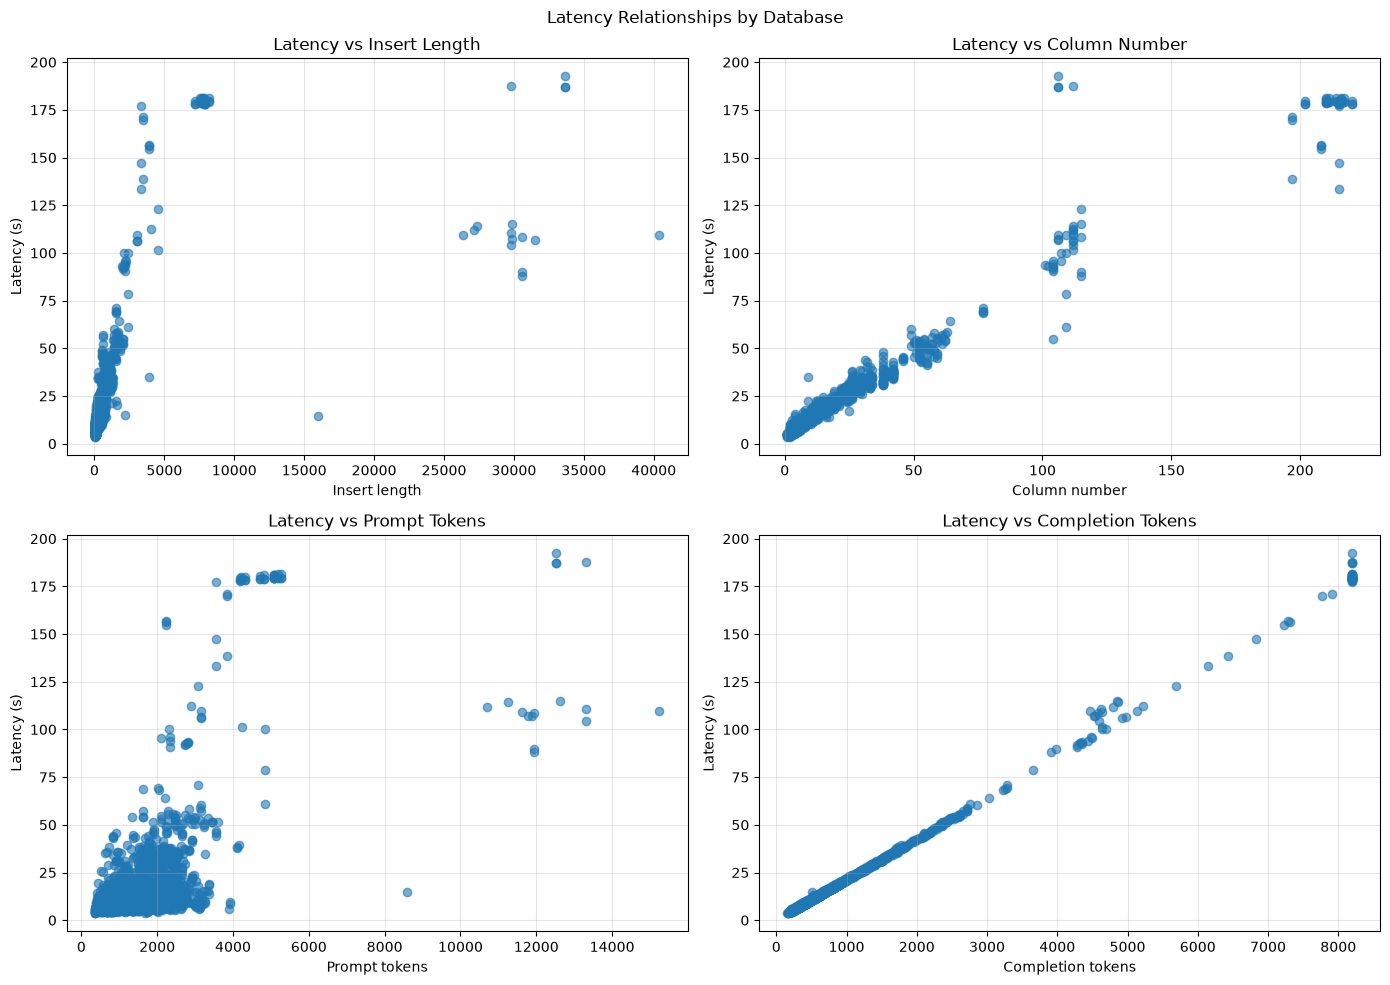

In [5]:
def plot_latency_relationships(calls):
    latencies = []
    insert_lengths = []
    column_numbers = []
    prompt_tokens = []
    completion_tokens = []

    for call in calls:
        insert_full = call.attributes.get("insert_full", "")
        if not insert_full:
            continue

        latency = (call.ended_at - call.started_at).total_seconds()
        if latency is None:
            continue

        column_number = call.attributes.get("insert_column_number", 0)

        output = getattr(call, "output", None)
        prompt_tokens_value = None
        completion_tokens_value = None
        if isinstance(output, dict):
            prompt_tokens_value = output.get("prompt_tokens")
            completion_tokens_value = output.get("completion_tokens")
        elif output is not None:
            prompt_tokens_value = getattr(output, "prompt_tokens", None)
            completion_tokens_value = getattr(output, "completion_tokens", None)

        latencies.append(latency)
        insert_lengths.append(len(insert_full))
        column_numbers.append(column_number)
        prompt_tokens.append(prompt_tokens_value)
        completion_tokens.append(completion_tokens_value)

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    axes[0, 0].scatter(insert_lengths, latencies, alpha=0.6)
    axes[0, 0].set_xlabel("Insert length")
    axes[0, 0].set_ylabel("Latency (s)")
    axes[0, 0].set_title("Latency vs Insert Length")
    axes[0, 0].grid(True, alpha=0.3)

    axes[0, 1].scatter(column_numbers, latencies, alpha=0.6)
    axes[0, 1].set_xlabel("Column number")
    axes[0, 1].set_ylabel("Latency (s)")
    axes[0, 1].set_title("Latency vs Column Number")
    axes[0, 1].grid(True, alpha=0.3)

    axes[1, 0].scatter(prompt_tokens, latencies, alpha=0.6)
    axes[1, 0].set_xlabel("Prompt tokens")
    axes[1, 0].set_ylabel("Latency (s)")
    axes[1, 0].set_title("Latency vs Prompt Tokens")
    axes[1, 0].grid(True, alpha=0.3)

    axes[1, 1].scatter(completion_tokens, latencies, alpha=0.6)
    axes[1, 1].set_xlabel("Completion tokens")
    axes[1, 1].set_ylabel("Latency (s)")
    axes[1, 1].set_title("Latency vs Completion Tokens")
    axes[1, 1].grid(True, alpha=0.3)

    fig.suptitle("Latency Relationships by Database")
    plt.tight_layout()
    plt.show()

plot_latency_relationships(calls)

In [5]:
first_correct = len([c for c in calls if c.attributes.get("prediction_attempt", -1) == 1 and c.output and c.output.get("prediction_error") is None])
second_correct = len([c for c in calls if c.attributes.get("prediction_attempt", -1) == 2 and c.output and c.output.get("prediction_error") is None])
third_correct = len([c for c in calls if c.attributes.get("prediction_attempt", -1) == 3 and c.output and c.output.get("prediction_error") is None])
print(f"First attempt correct: {first_correct}, Second attempt correct: {second_correct}, Third attempt correct: {third_correct}")

first_incorrect = len([c for c in calls if c.attributes.get("prediction_attempt", -1) == 1 and c.output and c.output.get("prediction_error") is not None])
second_incorrect = len([c for c in calls if c.attributes.get("prediction_attempt", -1) == 2 and c.output and c.output.get("prediction_error") is not None])
print(f"First attempt incorrect: {first_incorrect}, Second attempt incorrect: {second_incorrect}")

incorrect_number_of_columns = len([c for c in calls if c.attributes.get("prediction_attempt", -1) == 3 and c.output and c.output.get("prediction_error") == "IncorrectNumberOfColumnsError"])
incorrect_json = len([c for c in calls if c.attributes.get("prediction_attempt", -1) == 3 and c.output and c.output.get("prediction_error") == "JSONDecodeError"])
incorrect_json_max_tokens = len([c for c in calls if c.attributes.get("prediction_attempt", -1) == 3 and c.output and c.output.get("prediction_error") == "JSONDecodeError" and c.output.get("completion_tokens", 0) == 8192])
print(f"Incorrect number of columns: {incorrect_number_of_columns}, Incorrect JSON: {incorrect_json} (With max tokens: {incorrect_json_max_tokens})")

duplicate_column_names = len([c for c in calls if c.output and c.output.get("prediction_error") is None and len(c.output.get("predicted_column_names")) != len(set(c.output.get("predicted_column_names")))])
print(f"Duplicate column names: {duplicate_column_names}")

First attempt correct: 784, Second attempt correct: 84, Third attempt correct: 14
First attempt incorrect: 141, Second attempt incorrect: 57
Incorrect number of columns: 22, Incorrect JSON: 2 (With max tokens: 0)
Duplicate column names: 0


In [12]:
def is_same_value(value1, value2):
    if value1 == value2:
        return True
    
    try:
        # Attempt to convert both values to float for comparison
        return abs(float(value1) - float(value2)) < 1e-9
    except:
        pass

    fuzz_ratio = fuzz.ratio(str(value1), str(value2))
    if fuzz_ratio >= 90:
        return True
    
    return False

def analyze_output_values(calls):
    correct_counter = 0
    wrong_position_counter = 0
    missing_counter = 0
    not_occuring_counter = 0

    found_counter = 0

    for call in calls:
        if not call.output:
            continue

        if call.output.get("prediction_error") is not None:
            continue

        if len(call.output.get("predicted_column_names")) != len(set(call.output.get("predicted_column_names"))):
            continue

        output = json.loads(call.output.get("raw"))
        try:
            insert_data = parse_insert(call.attributes.get("insert_full"))
            insert_values = [v[1:-1] if isinstance(v, str) and len(v) > 0 and (v[0] == '"' or v[0] == "'") else v for v in insert_data["values"][0]]
            insert_values = [v.replace("''", "'") if isinstance(v, str) else v for v in insert_values]
        except:
            print(f"Failed to parse insert statement: {call.attributes.get('insert_full')}")
            continue

        col_prediction_values = [col_prediction["value"] for col_prediction in output["columns"]]
        col_prediction_values = [v[1:-1] if isinstance(v, str) and len(v) > 0 and (v[0] == '"' or v[0] == "'") else v for v in col_prediction_values]
        col_prediction_values = [v.replace("''", "'") if isinstance(v, str) else v for v in col_prediction_values]

        cols_used = [0 for _ in range(len(col_prediction_values))]

        for i, insert_value in enumerate(insert_values):
            if i < len(col_prediction_values) and is_same_value(insert_value, col_prediction_values[i]):
                correct_counter += 1
                cols_used[i] = 1
                continue

            try:
                position = col_prediction_values.index(insert_value)
                wrong_position_counter += 1
                cols_used[position] = 1
                # print(f"Insert value '{insert_value}' from position {i} found at position {position} in prediction values.")
            except:
                missing_counter += 1
                print(f"Insert value\t '{insert_value}' from position {i} not found in prediction values.")

        any_found = False
        for i, used in enumerate(cols_used):
            if used == 0:
                print(f"Predicted value\t '{col_prediction_values[i]}' at position {i} was not used in the insert values.")
                any_found = True
        
        if any_found:
            print("Insert values:\t\t\t", insert_values)
            print("Predicted columns for values:\t", col_prediction_values)
            found_counter += 1
        not_occuring_counter += cols_used.count(0)

        # if found_counter >= 5:
        #     return

    print(f"Correct values: {correct_counter}, Wrong position: {wrong_position_counter}, Missing values: {missing_counter}, Not occurring values: {not_occuring_counter}")

analyze_output_values(calls)

Insert value	 '150120683.0' from position 16 not found in prediction values.
Predicted value	 '/m/01wq__' at position 13 was not used in the insert values.
Insert values:			 ['Taketa', 'city in Ōita Prefecture, Japan', 'Okajoshi.jpg', '442089', 'Taketa, Oita', 'Japan', 'Oita Prefecture', '32.973611111111', 'https://www.city.taketa.oita.jp/', 'city of Japan', '304309.0', '/m/01wq__', '19688.0', '069e3c5d-bf6a-480b-a06f-7eb9c58f4dbc', 'Category:Taketa, Oita', '1850878', '150120683.0', '477.589999999999975', '9000020442089', '竹田市', 'UTC+09:00', 'Taketa in Oita Prefecture Ja.svg', 'jp/9000020442089', 'r9LzY7', '竹田市', '890519187.0', 'lccn-n82104342', 'Ōita', '+2005-04-01T00:00:00Z', 'Taketa', '34518.0', 'たけたし']
Predicted columns for values:	 ['Taketa', 'city in Ōita Prefecture, Japan', 'Okajoshi.jpg', '442089', 'Taketa, Oita', 'Japan', 'Oita Prefecture', '32.973611111111', 'https://www.city.taketa.oita.jp/', 'city of Japan', '304309.0', '/m/01wq__', '19688.0', '/m/01wq__', '069e3c5d-bf6a-48

In [11]:
def predicted_new_table(calls):
    total_predictions = 0
    new_table_prediction = 0

    for call in calls:
        if not call.output:
            continue

        if call.output.get("prediction_error", None) is not None:
            continue

        predicted_table = call.output.get("predicted_table_name", None)
        database_state = call.attributes.get("insert_database_state", {})

        if not predicted_table:
            continue

        total_predictions += 1
        if predicted_table not in database_state.keys():
            new_table_prediction += 1

    print(f"Predicted a new table in {new_table_prediction} out of {total_predictions} cases")

predicted_new_table(calls)

Predicted a new table in 63 out of 900 cases


In [8]:
def predicted_different_table_in_retry(calls):
    for call in calls:
        if call.attributes.get("prediction_attempt") < 2:
            continue

        if not call.output:
            continue

        new_predicted_table_name = call.output.get("predicted_table_name", None)
        if new_predicted_table_name is None:
            continue

        old_prediction = [c for c in calls if c.attributes.get("insert_full") == call.attributes.get("insert_full") and c.attributes.get("prediction_attempt") == call.attributes.get("prediction_attempt") - 1]
        if not old_prediction:
            print("Found no previous prediction")
        old_prediction = old_prediction[0]
        
        old_predicted_table_name = old_prediction.output.get("predicted_table_name", None)
        if old_predicted_table_name is None:
            continue

        if new_predicted_table_name != old_predicted_table_name:
            print(f"Prediction mismatch with old prediction '{old_predicted_table_name}' and new prediction '{new_predicted_table_name}'")

predicted_different_table_in_retry(calls)

Prediction mismatch with old prediction 'match_results' and new prediction 'cricketscores'
Prediction mismatch with old prediction 'genre_movies' and new prediction 'location_info'
Prediction mismatch with old prediction 'languages' and new prediction 'location_info'
Prediction mismatch with old prediction 'languages' and new prediction 'genre_movies'
Prediction mismatch with old prediction 'role_mapping' and new prediction 'role_mapping_table'
Prediction mismatch with old prediction 'accidents' and new prediction 'accident_details'
